# <div style="background-color:rgba(255, 255, 255, 0.1); text-align:center; vertical-align: middle; padding:40px 0; margin-top:30px"><span style="color:rgba(235, 235, 235, 1);"> Extinction Method</span></span></div>

In [2]:
# Hide unnecessary warnings.
import warnings
warnings.filterwarnings('ignore')

# Import PHYS231.py and then run the installer function.
import PHYS231
PHYS231.Installer()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm # used to generate a sequence of colours for plotting
import pandas as pd
import scipy.stats as sp
from scipy.optimize import curve_fit
from IPython.display import HTML as html_print
from IPython.display import display, Markdown, Latex
import uncertainties
import math
import sys

## Proceedure: Method 1 Extinction

1. Turn on laser and set polarizer to 90. Adjust till centered. USing clear bag to see red dot on photodiode.

2. Connect solenoid and write down Current going to Solenoid keeping . Only 3 A for around 30 seconds or 10 A for very short peiods of time.

3. Slowly turn polarizer until the polarizer till you achieve maximum output intensity, in volts at a resistor level.

4. Repeat for a variety of magnetic fields


Note you must have a material inside soleoid to observe a change.

Note we are using sample SF-57 for our glass rod.

In [7]:
I = np.array([1.0, 0.5, 1.5, 2, 2.5 ])   # A

B = (11.1*I)/1000 #T

l = 15 #cm

theta_0 = 275

theta_m = np.array([276, 275, 276, 277, 278]) # Degrees ~ 2 degrees error
err_theta = np.array([2,2,2,2,2])



diff_theta = abs(theta_0 - theta_m)
err_diff_theta = err_theta*2

diff_theta_rad = np.radians(diff_theta)  # Conversion of diff theta from degrees to radians.
err_diff_theta_rad = np.radians(err_diff_theta)

r = 10000 # ohms

print(diff_theta_rad, err_diff_theta_rad)
## At 90 the maximum extinction for red laser and SF 57 the intensity in 24.79 mV with magnetic field off.

## Did not record: Intensity = np.array([ ]) # mV DC

[0.01745329 0.         0.01745329 0.03490659 0.05235988] [0.06981317 0.06981317 0.06981317 0.06981317 0.06981317]


$y = m\,x + b$

This is a **WEIGHTED** fit.

,,Value,Units
slope,$m =$,2.20+/-0.31,T/A
$y$-intercept,$b =$,-0.0122+/-0.0058,T


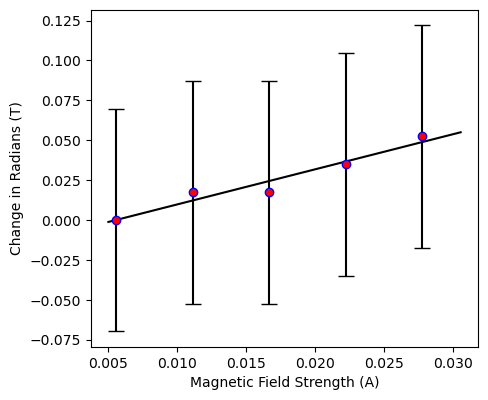

In [9]:
slope, intercept, err_slope, err_intercept, fig = PHYS231.LinearFit(
    xData=B,
    yData=diff_theta_rad,
    yErrors=err_diff_theta_rad,
    xlabel="Magnetic Field Strength",
    ylabel="Change in Radians",
    xUnits="A",
    yUnits="T",
    fill=False
)

In [11]:
## Calculating the Verdet Constant

L = 0.08 # Length in m

V = slope/L # Verdet Constant in T * m
print(V)

27.516452234887012
